<a href="https://colab.research.google.com/github/v-c-sch/DSF-DCBP-Rep.-SCHV/blob/main/DSF_Mid_Term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DSF Midterm Project

---


###1. Answer background questions, and upload them to your github


**1.1 Which packages are available for ML? Describe the pros and cons and document the availability**

Common ML packages include Scikit-learn, TensorFlow, PyTorch, Keras, and XGBoost. Scikit-learn is easy to use but not suited for deep learning. TensorFlow and PyTorch support deep learning and GPU usage but are more complex. Keras is user-friendly but less flexible. XGBoost is fast and accurate but less interpretable. All are available via Python (pip/conda).


**1.2 What is Chembl? How do you access it?**

ChEMBL is a database of bioactive molecules with drug-like properties. It contains chemical structures, biological activity data and targetet proteins.
It can be accessed trough their website, the python API or the data sets can be downloaded directly.


**1.3 What is machine learning, and how does it differ from traditional programming?**

Machine learning is a method where computers learn patterns from data instead of being explicitly programmed. With programming the computers produce an output according to previousely given rules. Machine learning causes the computer to create rules itself given the data it received. The model made is then used to predict possible outcomes.


**1.4 What are the key concepts and techniques in machine learning?**

Key concepts in machine learning include features, which are the input variables used by the model, and labels, which represent the desired output. The process of training involves adjusting a model based on training data so that it can make accurate predictions. Important techniques include data splitting into training and testing sets, feature engineering, and model evaluation. Concepts such as overfitting and underfitting are also crucial, as they describe whether a model learns too much noise or too little information from the data.


**1.5 What are the different types of machine learning algorithms?**

Machine learning algorithms can be divided into three main categories. Supervised learning uses labeled data to train models for tasks such as classification and regression. Unsupervised learning works with unlabeled data and aims to find patterns or groupings, such as clustering. Reinforcement learning is a different approach in which an agent learns by interacting with an environment and receiving rewards or penalties.

**1.6 What are the common applications of machine learning?**

Machine learning is used in many fields. In chemistry and drug discovery, it helps predict biological activity of compounds. In everyday applications, it is used for image recognition, speech recognition, and recommendation systems such as those used by streaming platforms. It is also widely applied in finance for fraud detection and risk analysis.

**1.7 How do you evaluate the performance of a machine learning model?**

The performance of a machine learning model is evaluated using specific metrics that depend on the task. For classification problems, common metrics include accuracy, precision, recall, and the F1-score. Another important measure is the ROC-AUC score, which evaluates how well a model distinguishes between classes. The evaluation is typically performed on a test dataset that was not used during training to ensure that the model generalizes well to new data.

**1.8 How do you prepare data for use in a machine learning model?**

Data preparation is an essential step in machine learning. It involves cleaning the data by removing errors or missing values, transforming the data into a suitable format, and normalizing or scaling features if necessary. In cheminformatics, molecular structures are often converted into numerical representations such as fingerprints. The data is then split into training and testing sets to allow proper evaluation of the model.

**1.9 What are some common challenges in machine learning, and how can they be addressed?**

Machine learning faces several challenges. One common issue is overfitting, where a model performs well on training data but poorly on new data; this can be addressed using techniques such as regularization or cross-validation. Poor data quality can negatively impact performance and must be handled through careful cleaning and preprocessing. Imbalanced datasets can also be problematic and may require resampling techniques. Additionally, complex models can be difficult to interpret, so simpler models or explainability methods may be used.

**1.10 What are some resources and tools available to help you learn and practice machine learning?**

There are many resources available for learning machine learning. Online platforms such as Kaggle provide datasets and practical challenges. Educational platforms like Coursera offer structured courses. Documentation from libraries such as Scikit-learn is also very useful. In addition, tools like Google Colab allow users to run machine learning code in the cloud without needing powerful local hardware. GitHub is another important resource for exploring existing projects and sharing code.



---


In [1]:
!pip -q install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 26.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
from warnings import filterwarnings

# Silence some expected warnings
filterwarnings("ignore")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# Neural network specific libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

%matplotlib inline

In [3]:
# Set path to this notebook
HERE = Path(_dh[-1])
DATA = HERE / "data"

### Data preparation

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load kinase data from Google Drive
df = pd.read_csv("/content/drive/MyDrive/DSF/MidTermProject/kinase.csv")

# one target only
df = df[df["target_chembl_id"] == "CHEMBL2971"].copy()

# keep only valid nM values
df = df[df["standard_units"] == "nM"].copy()
df = df[df["standard_value"] > 0].copy()

# convert nM to pIC50
df["pIC50"] = 9 - np.log10(df["standard_value"])

# rename smiles column to match notebook
df = df.rename(columns={"smiles": "canonical_smiles"})

# reset index
df = df.reset_index(drop=True)

print("Shape of dataframe:", df.shape)
df.head()

Shape of dataframe: (5429, 7)


,Unnamed: 0,molecule_chembl_id,standard_value,standard_units,target_chembl_id,canonical_smiles,pIC50
0,614,CHEMBL388978,4.70,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.327902
1,615,CHEMBL388978,2.00,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.698970
2,616,CHEMBL388978,2.30,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.638272
3,617,CHEMBL388978,2.00,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.698970
4,618,CHEMBL388978,0.31,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,9.508638


In [6]:
# Check the dimension and missing value of the data
print("Shape of dataframe : ", df.shape)
df.info()

Shape of dataframe :  (5429, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5429 entries, 0 to 5428
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5429 non-null   int64  
 1   molecule_chembl_id  5429 non-null   object 
 2   standard_value      5429 non-null   float64
 3   standard_units      5429 non-null   object 
 4   target_chembl_id    5429 non-null   object 
 5   canonical_smiles    5429 non-null   object 
 6   pIC50               5429 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 297.0+ KB


In [7]:
# Look at head
df.head()
# NBVAL_CHECK_OUTPUT

,Unnamed: 0,molecule_chembl_id,standard_value,standard_units,target_chembl_id,canonical_smiles,pIC50
0,614,CHEMBL388978,4.70,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.327902
1,615,CHEMBL388978,2.00,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.698970
2,616,CHEMBL388978,2.30,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.638272
3,617,CHEMBL388978,2.00,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.698970
4,618,CHEMBL388978,0.31,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,9.508638


In [8]:
# Keep necessary columns
chembl_df = df[["molecule_chembl_id", "canonical_smiles", "pIC50"]].dropna()

# remove duplicates
chembl_df = chembl_df.drop_duplicates(subset=["molecule_chembl_id"])

# optional: smaller sample for Colab test run
chembl_df = chembl_df.sample(min(len(chembl_df), 3000), random_state=42)

print("Shape of cleaned dataframe:", chembl_df.shape)
chembl_df.head()

Shape of cleaned dataframe: (3000, 3)


,molecule_chembl_id,canonical_smiles,pIC50
830,CHEMBL3357978,CS(=O)(=O)N1CCC[C@H](Nc2nccnc2-c2cnc3[nH]ccc3n...,7.443697
1236,CHEMBL3642317,CN1CCN(Cc2ccc(Nc3nc4cccc(-c5cccc(S(C)(=O)=O)c5...,7.931814
2056,CHEMBL3896481,CN(c1ccc(C#N)cn1)[C@@H]1CCN(c2ncnc3[nH]ccc23)C1,10.259637
1044,CHEMBL3642369,CN1C(=O)Cc2cc(Nc3nc4c(NCc5cccnc5N(C)S(C)(=O)=O...,7.561933
2251,CHEMBL4281393,N#CN[C@H]1CCc2ccc(-c3ncnc4[nH]ccc34)cc21,5.778325


In [9]:
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.
    """

    # Convert smiles to RDKit mol object
    mol = Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    else:
        print(f"Warning: Wrong method specified: {method}." " Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

In [10]:
chembl_df["fingerprints_df"] = chembl_df["canonical_smiles"].apply(smiles_to_fp)

# remove rows where fingerprint creation failed
chembl_df = chembl_df[chembl_df["fingerprints_df"].notna()].copy()

print("Shape of dataframe:", chembl_df.shape)
chembl_df.head(3)

Shape of dataframe: (3000, 4)


,molecule_chembl_id,canonical_smiles,pIC50,fingerprints_df
830,CHEMBL3357978,CS(=O)(=O)N1CCC[C@H](Nc2nccnc2-c2cnc3[nH]ccc3n...,7.443697,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1236,CHEMBL3642317,CN1CCN(Cc2ccc(Nc3nc4cccc(-c5cccc(S(C)(=O)=O)c5...,7.931814,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2056,CHEMBL3896481,CN(c1ccc(C#N)cn1)[C@@H]1CCN(c2ncnc3[nH]ccc23)C1,10.259637,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [11]:
# Split the data into training and test set
x_train, x_test, y_train, y_test = train_test_split(
    chembl_df["fingerprints_df"], chembl_df[["pIC50"]], test_size=0.3, random_state=42
)

# Print the shape of training and testing data
print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)
# NBVAL_CHECK_OUTPUT

Shape of training data: (2100,)
Shape of test data: (900,)


### Define neural network


In [12]:
def neural_network_model(hidden1, hidden2):
    """
    Creating a neural network from two hidden layers
    using ReLU as activation function in the two hidden layers
    and a linear activation in the output layer.

    Parameters
    ----------
    hidden1 : int
        Number of neurons in first hidden layer.

    hidden2: int
        Number of neurons in second hidden layer.

    Returns
    -------
    model
        Fully connected neural network model with two hidden layers.
    """

    model = Sequential()
    # First hidden layer
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # Second hidden layer
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # Output layer
    model.add(Dense(1, activation="linear", name="layer3"))

    # Compile model
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

### Train the model


In [13]:
# Neural network parameters
batch_sizes = [16, 32, 64]
nb_epoch = 50
layer1_size = 64
layer2_size = 32

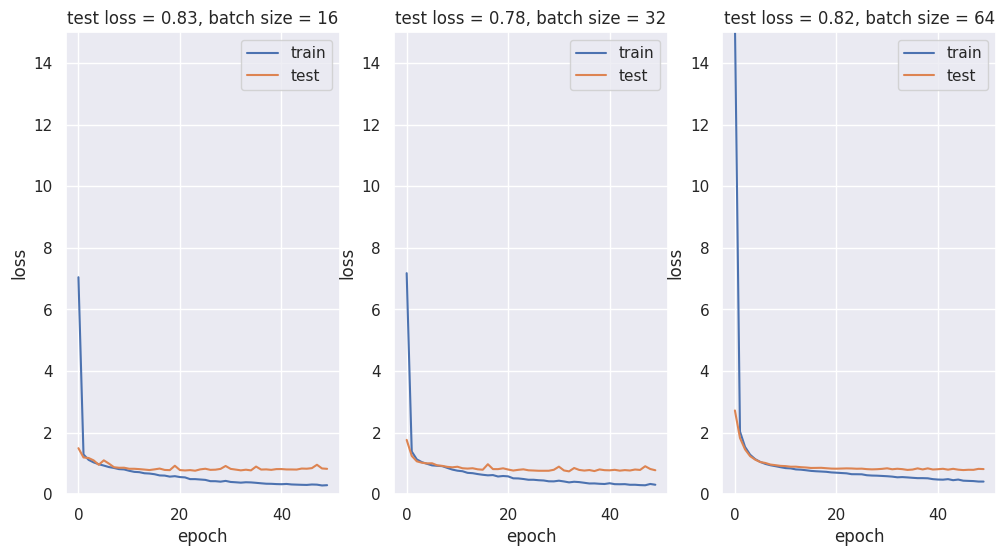

In [14]:
# Plot
fig = plt.figure(figsize=(12, 6))
sns.set(color_codes=True)
for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)

    # Fit model on x_train, y_train data
    history = model.fit(
        np.array(list((x_train))).astype(float),
        y_train.values,
        batch_size=batch,
        validation_data=(np.array(list((x_test))).astype(float), y_test.values),
        verbose=0,
        epochs=nb_epoch,
    )
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.ylim((0, 15))
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, " f"batch size = {batch}"
    )
plt.show()

In [15]:
# Save the trained model
filepath = DATA / "best_weights.weights.h5"
checkpoint = ModelCheckpoint(
    str(filepath),
    monitor="loss",
    verbose=0,
    save_best_only=True,
    mode="min",
    save_weights_only=True,
)
callbacks_list = [checkpoint]

# Fit the model
model.fit(
    np.array(list((x_train))).astype(float),
    y_train.values,
    epochs=nb_epoch,
    batch_size=16,
    callbacks=callbacks_list,
    verbose=0,
)

### Evaluation & prediction on test set


In [16]:
# Evalute the model
print(f"Evaluate the model on the test data")
scores = model.evaluate(np.array(list((x_test))), y_test.values, verbose=0)
print(f" loss: {scores[0]:.2f}")
print(f" mse (same as loss): {scores[1]:.2f}")
print(f" mae: {scores[2]:.2f}")

Evaluate the model on the test data
 loss: 1.00
 mse (same as loss): 1.00
 mae: 0.76


The mean absolute error on the test set is as below $1.0$ which given the range of pIC50 values is pretty low.

We now predict the pIC50 values on the test data.

In [17]:
# Predict pIC50 values on x_test data
y_pred = model.predict(np.array(list((x_test))))

# Print 5 first pIC50 predicted values
first_5_prediction = [print(f"{value[0]:.2f}") for value in y_pred[0:5]]

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
6.97
7.25
7.30
6.97
6.95


#### Scatter plot

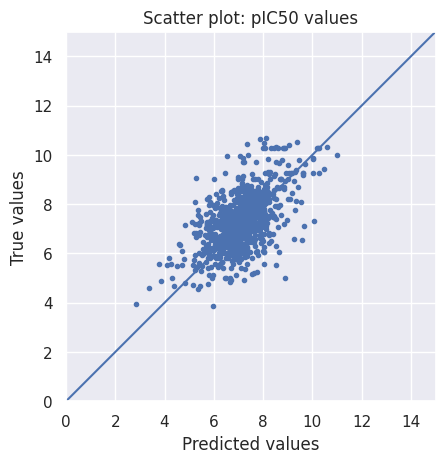

In [18]:
# Scatter plot
limits = 0, 15
fig, ax = plt.subplots()
ax.scatter(y_pred, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()


---

###5. Gain access to Ubelix

**5.1 What is Ubelix?**

Ubelix is the High Performance Computing unit of the university of bern
UBELIX is an acronym and stands for University of Bern Linux Cluster

**5.2 How do you gain access?**

By requesting access over the unibe support dialog window

**5.3 How do you submit a job?**

Every job submission starts with a resources allocation (nodes, cores, memory). An allocation is requested for a specific amount of time, and can be created using the salloc, sbatch commands. Whereas salloc and sbatch only create resource allocations, srun launches parallel tasks within such a resource allocation.

**5.4 Who can have access?**

The infrastructure is available to all University personnel for their scientific work. The cluster can also be used by students within a scope of a thesis or a course.

**5.5 What resources are available there?**

Currently, the UBELIX cluster runs around 280 compute nodes featuring ~15k CPU cores and ~180 GPUs with almost one million GPU cores.

---
